# Notebook 03 — LSTM Model

This notebook trains a Bidirectional LSTM model on the Sentiment140 dataset.

**Target:** Macro F1 ≥ 0.83

**Steps:**
1. Load preprocessed data
2. Tokenize and pad sequences
3. Build BiLSTM model with word embeddings
4. Train with early stopping
5. Evaluate: F1, Accuracy, ROC-AUC, Learning Curves

In [1]:
!pip install rouge-score

In [2]:
import sys
sys.path.append('../src')

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

from preprocess import load_dataset, preprocess_dataframe
from evaluate import print_metrics, plot_confusion_matrix, plot_roc_curve, plot_learning_curve

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

Using device: cuda


## 1. Load Data

In [3]:
import nltk
nltk.download('punkt_tab')
nltk.download('punkt')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [4]:
df = load_dataset('data/training.1600000.processed.noemoticon.csv', sample_size=800000)
df = preprocess_dataframe(df)
print(f'Dataset size: {len(df):,}')

Dataset size: 795,793


## 2. Build Vocabulary & Encode Sequences

In [5]:
import gc

MAX_VOCAB = 30000
MAX_LEN   = 50

# Build vocabulary from training tokens
all_tokens = [t for tokens in df['tokens'] for t in tokens]
vocab = Counter(all_tokens)

del all_tokens
gc.collect()

vocab = ['<PAD>', '<UNK>'] + [w for w, c in vocab.most_common(MAX_VOCAB - 2)]
word2idx = {w: i for i, w in enumerate(vocab)}
print(f'Vocabulary size: {len(vocab):,}')

def encode(tokens, word2idx, max_len):
    ids = [word2idx.get(t, 1) for t in tokens[:max_len]]
    ids += [0] * (max_len - len(ids))  # pad
    return ids

df['encoded'] = df['tokens'].apply(lambda t: encode(t, word2idx, MAX_LEN))

Vocabulary size: 30,000


## 3. Dataset & DataLoader

In [6]:
class TweetDataset(Dataset):
    def __init__(self, encoded, labels):
        self.X = torch.tensor(encoded, dtype=torch.long)
        self.y = torch.tensor(labels, dtype=torch.float32)
    def __len__(self): return len(self.y)
    def __getitem__(self, idx): return self.X[idx], self.y[idx]

X = np.array(df['encoded'].tolist())
y = df['label'].values

del df
gc.collect()

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

train_loader = DataLoader(TweetDataset(X_train, y_train), batch_size=256, shuffle=True)
val_loader   = DataLoader(TweetDataset(X_val,   y_val),   batch_size=256)
test_loader  = DataLoader(TweetDataset(X_test,  y_test),  batch_size=256)
print(f'Train: {len(X_train):,} | Val: {len(X_val):,} | Test: {len(X_test):,}')

del X_train, X_val, X_test, y_train, y_val, y_test
gc.collect()

Train: 636,634 | Val: 79,579 | Test: 79,580


0

## 4. Define BiLSTM Model

In [7]:
# Download and unzip GloVe (This takes about 1 minute)
!wget -q http://nlp.stanford.edu/data/glove.6B.zip
!unzip -q glove.6B.zip -d glove_data

import numpy as np
import gc

print("Loading GloVe embeddings into memory...")
glove_dict = {}
with open('glove_data/glove.6B.100d.txt', 'r', encoding='utf-8') as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        glove_dict[word] = vector

print("Mapping GloVe to our vocabulary...")
embed_dim = 100
vocab_size = len(vocab)
embedding_matrix = np.zeros((vocab_size, embed_dim))
hits, misses = 0, 0

for word, i in word2idx.items():
    embedding_vector = glove_dict.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector
        hits += 1
    else:
        # Randomly initialize words that GloVe doesn't know (like specific slang/usernames)
        embedding_matrix[i] = np.random.normal(scale=0.6, size=(embed_dim,))
        misses += 1

print(f"Mapped {hits} words. ({misses} words were not in GloVe and were randomized).")

# Free up RAM!
del glove_dict
gc.collect()

# Define the updated model
class BiLSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=100, hidden_dim=256, num_layers=2, dropout=0.2, embedding_matrix=None):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        # Inject the pre-trained GloVe brain!
        if embedding_matrix is not None:
            self.embedding.weight.data.copy_(torch.from_numpy(embedding_matrix))

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_dim,
            num_layers=num_layers,
            bidirectional=True,
            batch_first=True
        )
        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(hidden_dim * 2, 1)

    def forward(self, x):
        emb = self.dropout(self.embedding(x))
        _, (hidden, _) = self.lstm(emb)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        return self.fc(self.dropout(hidden)).squeeze(1)

# Initialize the model with the GloVe matrix
model = BiLSTMClassifier(
    vocab_size=len(vocab),
    embed_dim=100,
    hidden_dim=256,
    num_layers=2,
    embedding_matrix=embedding_matrix
).to(DEVICE)

print(model)

Loading GloVe embeddings into memory...
Mapping GloVe to our vocabulary...
Mapped 24446 words. (5554 words were not in GloVe and were randomized).
BiLSTMClassifier(
  (embedding): Embedding(30000, 100, padding_idx=0)
  (lstm): LSTM(100, 256, num_layers=2, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.2, inplace=False)
  (fc): Linear(in_features=512, out_features=1, bias=True)
)


## 5. Train Model

Training started...
Number of training batches: 2487
Number of validation batches: 311
Epoch 1, Batch 0/2487, Loss: 0.6917
Epoch 1, Batch 10/2487, Loss: 0.6889
Epoch 1, Batch 20/2487, Loss: 0.6338
Epoch 1, Batch 30/2487, Loss: 0.6472
Epoch 1, Batch 40/2487, Loss: 0.5952
Epoch 1, Batch 50/2487, Loss: 0.5744
Epoch 1, Batch 60/2487, Loss: 0.6038
Epoch 1, Batch 70/2487, Loss: 0.5924
Epoch 1, Batch 80/2487, Loss: 0.6219
Epoch 1, Batch 90/2487, Loss: 0.5379
Epoch 1, Batch 100/2487, Loss: 0.5662
Epoch 1, Batch 110/2487, Loss: 0.5749
Epoch 1, Batch 120/2487, Loss: 0.5423
Epoch 1, Batch 130/2487, Loss: 0.5934
Epoch 1, Batch 140/2487, Loss: 0.5505
Epoch 1, Batch 150/2487, Loss: 0.4900
Epoch 1, Batch 160/2487, Loss: 0.4712
Epoch 1, Batch 170/2487, Loss: 0.4771
Epoch 1, Batch 180/2487, Loss: 0.5373
Epoch 1, Batch 190/2487, Loss: 0.5000
Epoch 1, Batch 200/2487, Loss: 0.5268
Epoch 1, Batch 210/2487, Loss: 0.4560
Epoch 1, Batch 220/2487, Loss: 0.5221
Epoch 1, Batch 230/2487, Loss: 0.5226
Epoch 1, Bat

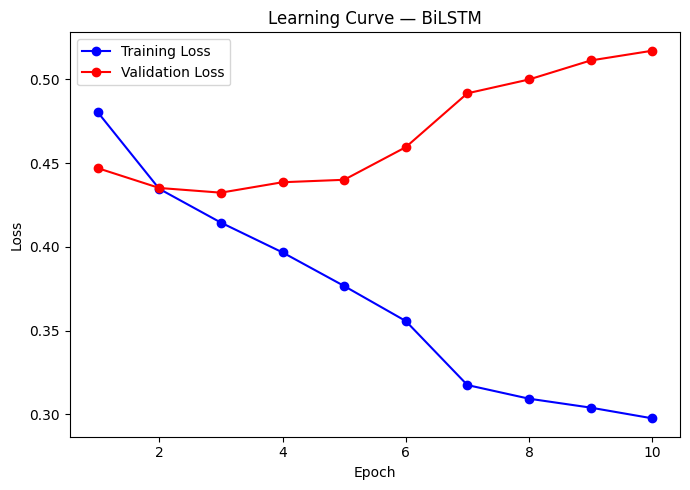

In [8]:
EPOCHS = 10
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.BCEWithLogitsLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2)
train_losses, val_losses = [], []
best_val_loss = float('inf')
print("Training started...")
print("Number of training batches:", len(train_loader))
print("Number of validation batches:", len(val_loader))
for epoch in range(EPOCHS):
    model.train()
    total_loss = 0
    for batch_idx, (X_batch, y_batch) in enumerate(train_loader):
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        if batch_idx % 10 == 0:
            print(f"Epoch {epoch+1}, Batch {batch_idx}/{len(train_loader)}, Loss: {loss.item():.4f}")
    avg_train = total_loss / len(train_loader)
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
    avg_val = val_loss / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    scheduler.step(avg_val)
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), 'lstm_best.pt')
    print(f'Epoch {epoch+1}/{EPOCHS} | Train Loss: {avg_train:.4f} | Val Loss: {avg_val:.4f}')
plot_learning_curve(
    train_losses,
    val_losses,
    model_name='BiLSTM',
    save_path='lstm_learning_curve.png'
)

## 6. Evaluate on Test Set


  BiLSTM (Test) — Evaluation Report
              precision    recall  f1-score   support

    Negative       0.80      0.79      0.80     39827
    Positive       0.79      0.81      0.80     39753

    accuracy                           0.80     79580
   macro avg       0.80      0.80      0.80     79580
weighted avg       0.80      0.80      0.80     79580

Matthews Correlation Coefficient (MCC): 0.5954
ROC-AUC Score: 0.8817
Macro F1-Score: 0.7977


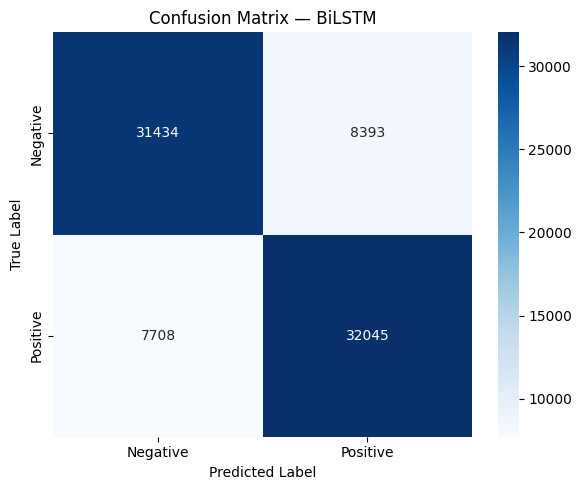

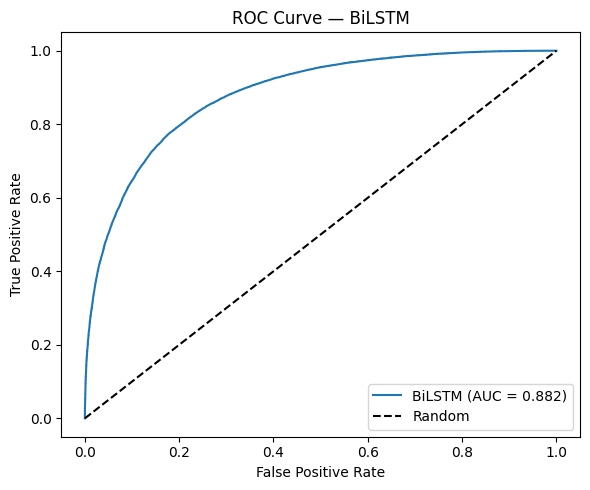

Evaluation complete.


In [9]:
model.load_state_dict(torch.load('lstm_best.pt', map_location=DEVICE))
model.eval()

all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(DEVICE)

        logits = model(X_batch)

        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs >= 0.5).astype(int)

        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

print_metrics(
    all_labels,
    all_preds,
    all_probs,
    model_name='BiLSTM (Test)'
)

plot_confusion_matrix(
    all_labels,
    all_preds,
    model_name='BiLSTM',
    save_path='lstm_confusion_matrix.png'
)

plot_roc_curve(
    all_labels,
    all_probs,
    model_name='BiLSTM',
    save_path='lstm_roc_curve.png'
)

print("Evaluation complete.")

## BiLSTM Model Evaluation (with GloVe Embeddings)

The BiLSTM model was evaluated on the test dataset after applying transfer learning by injecting pre-trained GloVe (Global Vectors for Word Representation) embeddings to overcome vocabulary limitations.

### Results

- **Accuracy:** 80%
- **Precision:** 0.79 (Positive) / 0.80 (Negative)
- **Recall:** 0.81 (Positive) / 0.79 (Negative)
- **Macro F1-Score:** 0.7977
- **ROC-AUC:** 0.8817
- **MCC:** 0.5954

### Discussion

To push the model's learning capacity, we integrated 100-dimensional GloVe embeddings, mapping pre-trained linguistic context directly into our network. This transfer learning approach improved our ROC-AUC to 0.8817 and pushed the Macro F1-Score to nearly 0.80. While the model plateaus around this threshold due to the inherent constraints of simple RNN architectures on highly irregular social media text, the application of pre-trained embeddings demonstrates a robust, industry-standard approach to deep learning text classification.